<!-- ARTHASAATHI-PROVENANCE -->
> ## ⚠️ This notebook is demo evidence, not the running system
>
> The logic below was migrated to **`ml/src/councils/risk/fraud.py`** and that module is what the application actually executes.
>
> **Role in the system:** Risk Council -> Fraud Protection Agent
>
> This notebook is preserved because its stored outputs are the record of the original analysis. **Editing the cells below will not change the system's behaviour** — change the module and its tests instead.
>
> Tests for this logic live under `tests/`, and every agent is covered by the cross-cutting contract suite in `tests/common/test_contracts.py`.


# 🔍 Fraud Detection & Scam Analysis — India MVP
> **Artha-Darshan | FinSafe Intelligence Engine**
>
> Run every cell from top to bottom. Fill in your API keys in **Section 3** and your case details in **Section 4**.
>
> Pipeline: *Evidence Gathering → Deterministic Risk Scoring → Single LLM Report*


## Section 1 — Install Dependencies

## Section 2 — Imports

In [48]:
import os, json, re, time, warnings, textwrap
from datetime import datetime, timezone
from urllib.parse import urlparse

import requests
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.colors as mcolors

import whois
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm

from groq import Groq   # pip install groq

warnings.filterwarnings("ignore")
print("✅ All imports successful.")

print(f"   matplotlib     : {matplotlib.__version__}")
print(f"   pandas         : {pd.__version__}")


✅ All imports successful.
   matplotlib     : 3.11.0
   pandas         : 3.0.3


In [49]:
from dotenv import load_dotenv
import os
load_dotenv()  # Load environment variables from .env file (for API keys)
# ── API Keys ──────────────────────────────────────────────────────────────────
TAVILY_API_KEY    = os.environ["TAVILY_API_KEY"]         # ← paste your Tavily key here
# SERPAPI_KEY       = os.environ["SERPAPI_KEY"]          # ← optional SerpAPI key
GROQ_API_KEY = os.environ["GROQ_API_KEY"]          # ← paste your Groq key here

# ── Push to env (so helper functions can read them) ───────────────────────────
os.environ["TAVILY_API_KEY"]    = TAVILY_API_KEY
# os.environ["SERPAPI_KEY"]       = SERPAPI_KEY
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

# ── Which search backend to use ───────────────────────────────────────────────
USE_TAVILY  = bool(TAVILY_API_KEY)
# USE_SERPAPI = bool(SERPAPI_KEY) and not USE_TAVILY
USE_GROQ = bool(GROQ_API_KEY)

print("Configuration:")
print(f"  Tavily  search : {'✅ enabled' if USE_TAVILY  else '⚠️  not configured (will use fallback)'}")
# print(f"  SerpAPI search : {'✅ enabled' if USE_SERPAPI else '⚠️  not configured'}")
print(f"  Groq LLM  : {'✅ key set'  if USE_GROQ else '❌  MISSING — set before Section 16'}")


python-dotenv could not parse statement starting at line 6


Configuration:
  Tavily  search : ✅ enabled
  Groq LLM  : ✅ key set


## Section 4 — User Input
> **Fill in the case details below, then run the cell.**  
> Every field is optional except `company_name`.


In [50]:
# ── Case Details ─────────────────────────────────────────────────────────────
company_name = "sbi-yono"

scheme_name = "tono-sbi-banking-and-lifestyle"

website_url = "https://apps.apple.com/in/app/yono-sbi-banking-and-lifestyle/id1231393474"

scheme_description = """
3 Steps to register on YONO app using your SBI Internet Banking credentials :​
Download YONO SBI app
Login using INB User ID and Password
Enter OTP, Set MPIN and You are done!
"""

whatsapp_message = """

"""

sms_message = """
ear Mr. SIDDHARTH SANJAY POTDAR,

Your account(s) details are available at your fingertips. You can view them online whenever required. For your convenience, please find attached your latest monthly statement.

Your e-account statement is protected by a password, which is the last five digits of customer registered mobile number and date of birth (DOB) in DDMMYY format registered with Bank, for example if mobile number is XXXXX12345 and DOB is 16th September 1982 then password will be 12345160982.

In case of any issues, please lodge a complaint online at contactcentre@sbi.co.in or by calling our 1800 1234 or 1800 2100 toll free numbers or by contacting your home branch.

With Best Regards,
Team SBI

** Please note: You will need Adobe Acrobat to open the attachment. Please do not reply to this email as it is a computer generated email.
"""





# ── Combine all text for phrase detection ─────────────────────────────────────
combined_text = " ".join([
    company_name, scheme_name, website_url,
    scheme_description, whatsapp_message, sms_message
]).lower()

print("✅ Input captured.")
print(f"   Company  : {company_name}")
print(f"   Scheme   : {scheme_name}")
print(f"   URL      : {website_url}")
print(f"   Combined text length: {len(combined_text)} chars")


✅ Input captured.
   Company  : sbi-yono
   Scheme   : tono-sbi-banking-and-lifestyle
   URL      : https://apps.apple.com/in/app/yono-sbi-banking-and-lifestyle/id1231393474
   Combined text length: 1145 chars


## Section 5 — Domain Analysis

In [51]:
import whois
import json
from datetime import datetime
from urllib.parse import urlparse


def analyze_domain(url: str) -> dict:

    result = {
        "domain": None,
        "registrar": None,
        "creation_date": None,
        "expiration_date": None,
        "domain_age_days": None,
        "country": None,
        "name_servers": [],
        "status": None,
        "error": None,
    }

    try:

        # Extract domain
        if not url.startswith(("http://", "https://")):
            url = "https://" + url

        parsed = urlparse(url)

        domain = parsed.netloc.lower().replace("www.", "")

        result["domain"] = domain

        # WHOIS lookup
        w = whois.whois(domain)

        def parse_date(value):
            if value is None:
                return None

            if isinstance(value, list):
                value = value[0]

            if isinstance(value, datetime):
                return value.replace(tzinfo=None)

            return None

        creation = parse_date(getattr(w, "creation_date", None))
        expiration = parse_date(getattr(w, "expiration_date", None))

        result["registrar"] = getattr(w, "registrar", None)

        result["country"] = getattr(w, "country", None)

        result["status"] = getattr(w, "status", None)

        name_servers = getattr(w, "name_servers", None)

        if name_servers:

            if isinstance(name_servers, set):
                name_servers = list(name_servers)

            if isinstance(name_servers, str):
                name_servers = [name_servers]

            result["name_servers"] = sorted(
                list(set(str(ns) for ns in name_servers))
            )

        if creation:

            result["creation_date"] = creation.isoformat()

            result["domain_age_days"] = (
                datetime.utcnow() - creation
            ).days

        if expiration:
            result["expiration_date"] = expiration.isoformat()

        # Fraud signal
        if result["domain_age_days"] is not None:

            age = result["domain_age_days"]

            if age < 30:
                result["risk_signal"] = "VERY_NEW_DOMAIN"

            elif age < 180:
                result["risk_signal"] = "NEW_DOMAIN"

            elif age < 365:
                result["risk_signal"] = "RECENT_DOMAIN"

            else:
                result["risk_signal"] = "ESTABLISHED_DOMAIN"

    except Exception as e:

        result["error"] = str(e)

    return result


# Example
domain_info = analyze_domain(website_url)

print("✅ Domain Analysis")
print(json.dumps(domain_info, indent=2, default=str))

✅ Domain Analysis
{
  "domain": "apps.apple.com",
  "registrar": "NOM-IQ Ltd dba Com Laude",
  "creation_date": "1987-02-19T05:00:00",
  "expiration_date": "2027-02-20T05:00:00",
  "domain_age_days": 14362,
  "country": "US",
  "name_servers": [
    "A.NS.APPLE.COM",
    "B.NS.APPLE.COM",
    "C.NS.APPLE.COM",
    "D.NS.APPLE.COM"
  ],
  "status": [
    "clientDeleteProhibited https://icann.org/epp#clientDeleteProhibited",
    "clientTransferProhibited https://icann.org/epp#clientTransferProhibited",
    "clientUpdateProhibited https://icann.org/epp#clientUpdateProhibited",
    "serverDeleteProhibited https://icann.org/epp#serverDeleteProhibited",
    "serverTransferProhibited https://icann.org/epp#serverTransferProhibited",
    "serverUpdateProhibited https://icann.org/epp#serverUpdateProhibited",
    "clientDeleteProhibited https://www.icann.org/epp#clientDeleteProhibited",
    "clientTransferProhibited https://www.icann.org/epp#clientTransferProhibited",
    "clientUpdateProhibited 

## Section 6 — Search Helper & Company Verification

In [52]:
# ── Generic search function (Tavily → SerpAPI → DuckDuckGo scrape fallback) ───

def web_search(query: str, num: int = 5) -> list[dict]:
    """
    Returns list of {title, url, snippet}.
    Tries Tavily → SerpAPI → DuckDuckGo HTML scrape.
    """
    results = []

    # 1) Tavily
    if os.environ.get("TAVILY_API_KEY"):
        try:
            resp = requests.post(
                "https://api.tavily.com/search",
                json={"api_key": os.environ["TAVILY_API_KEY"],
                      "query": query,
                      "max_results": num,
                      "search_depth": "basic"},
                timeout=15,
            )
            if resp.ok:
                for r in resp.json().get("results", []):
                    results.append({
                        "title":   r.get("title", ""),
                        "url":     r.get("url", ""),
                        "snippet": r.get("content", "")[:300],
                    })
                if results:
                    return results
        except Exception:
            pass

    # 2) SerpAPI
    if os.environ.get("SERPAPI_KEY"):
        try:
            resp = requests.get(
                "https://serpapi.com/search",
                params={"q": query, "api_key": os.environ["SERPAPI_KEY"],
                        "num": num, "hl": "en", "gl": "in"},
                timeout=15,
            )
            if resp.ok:
                for r in resp.json().get("organic_results", []):
                    results.append({
                        "title":   r.get("title", ""),
                        "url":     r.get("link", ""),
                        "snippet": r.get("snippet", "")[:300],
                    })
                if results:
                    return results
        except Exception:
            pass

    # 3) DuckDuckGo HTML (no API key needed, rate-limited)
    try:
        headers = {"User-Agent": "Mozilla/5.0 (FraudCheck/1.0)"}
        resp = requests.get(
            "https://html.duckduckgo.com/html/",
            params={"q": query},
            headers=headers,
            timeout=15,
        )
        soup = BeautifulSoup(resp.text, "html.parser")
        for a in soup.select(".result__title a")[:num]:
            href = a.get("href", "")
            snippet_tag = a.find_parent(".result").find(class_="result__snippet") if a.find_parent(".result") else None
            results.append({
                "title":   a.get_text(strip=True),
                "url":     href,
                "snippet": snippet_tag.get_text(strip=True)[:300] if snippet_tag else "",
            })
        if results:
            return results
    except Exception:
        pass

    return []  # all backends failed


# ── Company Verification ──────────────────────────────────────────────────────

COMPANY_REGISTRIES = ["mca.gov.in", "zaubacorp.com", "tofler.in", "quickcompany.in"]

def verify_company(company_name: str) -> dict:
    """Search for company on Indian corporate registries."""
    results_all = []
    for site in COMPANY_REGISTRIES:
        query = f'site:{site} "{company_name}"'
        results_all.extend(web_search(query, num=3))
    # Also generic search
    results_all.extend(web_search(f'"{company_name}" MCA registered company India', num=5))

    company_found   = len(results_all) > 0
    evidence_links  = list({r["url"] for r in results_all if r["url"]})[:10]
    evidence_snips  = [r["snippet"] for r in results_all if r["snippet"]][:5]

    return {
        "company_found":      company_found,
        "evidence_links":     evidence_links,
        "evidence_snippets":  evidence_snips,
    }


company_info = verify_company(company_name)
print("✅ Company Verification:")
print(f"   Found: {company_info['company_found']}")
print(f"   Links found: {len(company_info['evidence_links'])}")
for snip in company_info["evidence_snippets"][:2]:
    print(f"   · {snip[:120]}")


✅ Company Verification:
   Found: True
   Links found: 10
   · YONO INDUSTRIES PRIVATE LIMITED, SNO. 48/1/2 VRUNDAVAN PARK, NEW KATE ... Office No 201 301 Shed No Shanta BLDG Behind S
   · LUTON EXIM is a 18 year old company with registered office in West, Delhi. YONO INFO SOLUTIONS ,Near SBI Bank Uttam Naga


## Section 7 — RBI Warning Check

In [53]:
def check_rbi_alerts(company_name: str) -> dict:
    """Search for RBI warnings, caution notices, and enforcement actions."""
    queries = [
        f'"{company_name}" RBI warning',
        f'"{company_name}" RBI caution notice',
        f'"{company_name}" RBI alert unauthorized',
        f'"{company_name}" Reserve Bank of India fraud',
        f'site:rbi.org.in "{company_name}"',
    ]
    results_all = []
    for q in queries:
        results_all.extend(web_search(q, num=3))

    rbi_keywords = ["rbi", "reserve bank", "warning", "caution", "notice",
                    "unauthorized", "alert", "penalty", "enforcement"]

    matching = [
        r for r in results_all
        if any(kw in (r["title"] + r["snippet"]).lower() for kw in rbi_keywords)
    ]

    return {
        "rbi_warning_found": len(matching) > 0,
        "supporting_links":  list({r["url"] for r in matching})[:10],
        "warning_snippets":  [r["snippet"] for r in matching if r["snippet"]][:3],
    }


rbi_check = check_rbi_alerts(company_name)
print("✅ RBI Check:")
print(f"   Warning found: {rbi_check['rbi_warning_found']}")
print(f"   Supporting links: {len(rbi_check['supporting_links'])}")


✅ RBI Check:
   Warning found: True
   Supporting links: 8


## Section 8 — SEBI Registration Check

In [54]:
def check_sebi(company_name: str) -> dict:
    """Check SEBI registration and any SEBI enforcement actions."""
    queries = [
        f'site:sebi.gov.in "{company_name}"',
        f'"{company_name}" SEBI registered investment advisor',
        f'"{company_name}" SEBI registration number',
        f'"{company_name}" SEBI order penalty',
        f'"{company_name}" SEBI fraud unregistered',
    ]
    results_all = []
    for q in queries:
        results_all.extend(web_search(q, num=3))

    positive_kw = ["registered", "registration", "sebi.gov.in", "ria", "portfolio manager"]
    negative_kw = ["unregistered", "illegal", "fraud", "penalty", "order", "violation",
                   "ban", "debarred", "warned"]

    positive = [r for r in results_all if any(kw in (r["title"] + r["snippet"]).lower() for kw in positive_kw)]
    negative = [r for r in results_all if any(kw in (r["title"] + r["snippet"]).lower() for kw in negative_kw)]

    sebi_registered  = len(positive) > 0 and len(negative) == 0
    enforcement_found = len(negative) > 0

    return {
        "sebi_registered":     sebi_registered,
        "enforcement_found":   enforcement_found,
        "supporting_links":    list({r["url"] for r in results_all})[:10],
        "positive_snippets":   [r["snippet"] for r in positive][:2],
        "negative_snippets":   [r["snippet"] for r in negative][:2],
    }


sebi_check = check_sebi(company_name)
print("✅ SEBI Check:")
print(f"   Registered    : {sebi_check['sebi_registered']}")
print(f"   Enforcement   : {sebi_check['enforcement_found']}")


✅ SEBI Check:
   Registered    : False
   Enforcement   : True


## Section 9 — Complaint Search

In [55]:
from urllib.parse import urlparse
from tqdm import tqdm
import time

def normalize_company_name(text):
    text = text.strip()

    if text.startswith(("http://", "https://")):
        domain = urlparse(text).netloc.lower()
        domain = domain.replace("www.", "")
        return domain.split(".")[0]

    return text


def search_complaints(company_name: str) -> dict:

    company_name = normalize_company_name(company_name)

    queries = [
        f'{company_name} complaint',
        f'{company_name} scam',
        f'{company_name} fraud',
        f'{company_name} review',
        f'site:consumercomplaints.in {company_name}',
        f'site:mouthshut.com {company_name}',
        f'site:reddit.com {company_name} scam',
        f'{company_name} cheated money',
    ]

    results_all = []

    for q in tqdm(queries, desc="Complaint queries"):

        try:
            results = web_search(q, num=10)

            print(f"\nQuery: {q}")
            print(f"Results: {len(results)}")

            results_all.extend(results)

            time.sleep(0.5)

        except Exception as e:
            print(f"Search failed: {q}")
            print(e)

    # Deduplicate
    unique = {}
    for r in results_all:

        url = r.get("url")

        if url:
            unique[url] = r

    unique_results = list(unique.values())

    return {
        "company_name": company_name,
        "complaint_count": len(unique_results),
        "complaint_results": unique_results[:20]
    }


print("Running complaint search...")

complaints = search_complaints(company_name)

print(f"\n✅ Complaints found: {complaints['complaint_count']}")

for r in complaints["complaint_results"][:5]:

    print("\nTitle:", r.get("title", "N/A"))
    print("URL:", r.get("url", "N/A"))


Running complaint search...


Complaint queries:   0%|          | 0/8 [00:00<?, ?it/s]


Query: sbi-yono complaint
Results: 7


Complaint queries:  12%|█▎        | 1/8 [00:02<00:14,  2.14s/it]


Query: sbi-yono scam
Results: 10


...


Query: site:reddit.com sbi-yono scam
Results: 10


Complaint queries:  88%|████████▊ | 7/8 [00:11<00:01,  1.62s/it]


Query: sbi-yono cheated money
Results: 10


Complaint queries: 100%|██████████| 8/8 [00:13<00:00,  1.69s/it]


✅ Complaints found: 66

Title: How to complain to SBI YONO for the wrong transaction - Quora
URL: https://www.quora.com/How-do-I-complain-to-SBI-YONO-for-the-wrong-transaction

Title: SBI Complaint Escalation Process in India (Step-by-Step ... - Facebook
URL: https://www.facebook.com/complainthub.in/videos/sbi-complaint-escalation-process-in-india-step-by-step-guideimportant-contextalw/1468980721535147

Title: Customer Support - yono Business
URL: https://yonobusiness.sbi.bank.in/ContactUs

Title: Yono SBI se bank ka online complaint kaise kare | how to complain in yono sbi | Sbi complaint online
URL: https://www.youtube.com/watch?v=sF9tB6NmGng

Title: Online Complaint Management - SBIePay
URL: https://www.sbiepay.sbi/complainManagement/userValidation


## Section 10 — News Search

In [56]:
def search_news(company_name: str) -> dict:
    """Search for investigative news articles about the company."""
    queries = [
        f'"{company_name}" investigation ED CBI police',
        f'"{company_name}" fraud arrested India',
        f'"{company_name}" Ponzi scheme India',
        f'"{company_name}" SFIO investigation',
        f'"{company_name}" scam news',
    ]
    results_all = []
    for q in tqdm(queries, desc="News queries", leave=False):
        results_all.extend(web_search(q, num=4))
        time.sleep(0.3)

    news_domains = [
        "economictimes", "ndtv", "thehindu", "hindustantimes",
        "livemint", "businessstandard", "moneycontrol", "timesofindia",
        "scroll.in", "thewire", "newslaundry",
    ]

    articles = []
    seen = set()
    for r in results_all:
        if r["url"] in seen:
            continue
        seen.add(r["url"])
        domain = urlparse(r["url"]).netloc
        is_news = any(nd in domain for nd in news_domains)
        articles.append({
            "title":    r["title"],
            "source":   domain,
            "url":      r["url"],
            "snippet":  r["snippet"],
            "is_news":  is_news,
        })

    articles.sort(key=lambda x: x["is_news"], reverse=True)

    return {
        "article_count": len(articles),
        "articles":      articles[:15],
    }


print("Running news search …")
news = search_news(company_name)
print(f"\n✅ News articles found: {news['article_count']}")
for a in news["articles"][:3]:
    print(f"   · [{a['source']}] {a['title'][:80]}")


Running news search …



✅ News articles found: 19
   · [www.ndtv.com] SBI Officer Arrested For Facilitating Accounts For Cyber Criminals
   · [timesofindia.indiatimes.com] SBI manager among four arrested for stealing over Rs 2 crore from ...
   · [timesofindia.indiatimes.com] SBI says it hasn't received notice from SFIO, ED on probe into loans ...


## Section 11 — Website Reputation

In [57]:
import requests
def website_reputation(url: str) -> dict:
    """
    Checks:
      - HTTPS presence
      - Reachability
      - Domain age from earlier WHOIS result
      - Basic header signals
    """
    result = {
        "secure_connection":   False,
        "reachable":           False,
        "status_code":         None,
        "server":              None,
        "domain_age_days":     domain_info.get("domain_age_days"),
        "suspicious":          False,
        "flags":               [],
    }

    try:
        full_url = url if url.startswith("http") else "https://" + url
        result["secure_connection"] = full_url.startswith("https://")

        if not result["secure_connection"]:
            result["flags"].append("No HTTPS — connection is unencrypted")

        resp = requests.get(full_url, timeout=10, allow_redirects=True,
                            headers={"User-Agent": "Mozilla/5.0"})
        result["reachable"]   = True
        result["status_code"] = resp.status_code
        result["server"]      = resp.headers.get("Server", "Unknown")

        age = result["domain_age_days"]
        if age is not None and age < 180:
            result["flags"].append(f"Domain is only {age} days old (< 180 days)")

    except requests.exceptions.SSLError:
        result["flags"].append("SSL certificate error")
    except requests.exceptions.ConnectionError:
        result["flags"].append("Website unreachable")
    except Exception as exc:
        result["flags"].append(f"Check error: {exc}")

    result["suspicious"] = len(result["flags"]) > 0
    return result


web_rep = website_reputation(website_url)
print("✅ Website Reputation:")
print(json.dumps(web_rep, indent=2))


✅ Website Reputation:
{
  "secure_connection": true,
  "reachable": true,
  "status_code": 200,
  "server": "daiquiri/5",
  "domain_age_days": 14362,
  "suspicious": false,
  "flags": []
}


## Section 12 — Scam Phrase Detection

In [58]:
SCAM_TERMS = [
    "guaranteed returns",
    "risk free",
    "risk-free",
    "double your money",
    "fixed income",
    "assured profit",
    "assured returns",
    "100% return",
    "earn daily",
    "daily income",
    "no risk",
    "zero risk",
    "safe investment",
    "100% safe",
    "get rich",
    "passive income guarantee",
    "instant profit",
    "quick money",
    "easy money",
    "limited slots",
    "limited time offer",
    "exclusive offer",
    "secret formula",
    "insider tips",
    "jackpot",
    "monthly assured",
    "weekly profit",
    "fixed monthly",
    "no loss",
]

def detect_scam_phrases(text: str) -> dict:
    """Count and identify scam phrases in combined_text."""
    text_lower = text.lower()
    matched = [term for term in SCAM_TERMS if term in text_lower]
    return {
        "scam_term_count": len(matched),
        "matched_terms":   matched,
    }


scam_phrases = detect_scam_phrases(combined_text)
print("✅ Scam Phrase Detection:")
print(f"   Matches : {scam_phrases['scam_term_count']}")
print(f"   Terms   : {scam_phrases['matched_terms']}")


✅ Scam Phrase Detection:
   Matches : 0
   Terms   : []


## Section 13 — MLM / Pyramid Scheme Detection

In [59]:
MLM_TERMS = [
    "downline",
    "binary income",
    "team income",
    "referral income",
    "recruit members",
    "network marketing",
    "level income",
    "join our team",
    "direct selling",
    "matrix plan",
    "generation income",
    "sponsor",
    "recruitment bonus",
    "joining fee",
    "activation fee",
    "distributor",
    "upline",
    "pyramid",
    "chain marketing",
    "multi level",
    "multilevel",
    "downline bonus",
    "team bonus",
    "refer and earn",
]

def detect_mlm_phrases(text: str) -> dict:
    """Count and identify MLM/pyramid scheme phrases."""
    text_lower = text.lower()
    matched = [term for term in MLM_TERMS if term in text_lower]
    return {
        "mlm_count":    len(matched),
        "matched_terms": matched,
    }


mlm_phrases = detect_mlm_phrases(combined_text)
print("✅ MLM Phrase Detection:")
print(f"   Matches : {mlm_phrases['mlm_count']}")
print(f"   Terms   : {mlm_phrases['matched_terms']}")


✅ MLM Phrase Detection:
   Matches : 0
   Terms   : []


## Section 14 — Risk Scoring Engine

In [60]:
def calculate_risk_score(
    company_info: dict,
    domain_info:  dict,
    rbi_check:    dict,
    sebi_check:   dict,
    complaints:   dict,
    scam_phrases: dict,
    mlm_phrases:  dict,
) -> dict:
    """
    Deterministic risk scoring — no LLM involved.

    Rule weights
    ─────────────────────────────────────────────────────────────────────────
    Company not found in MCA / registries     +40
    RBI warning / caution notice found        +50
    SEBI enforcement action found             +30
    SEBI not registered (no positive hits)    +25
    Domain age < 180 days                     +20
    Domain age < 30  days                     +10 (additional)
    Complaint count > 10                      +20
    Complaint count > 50                      +40 (replaces +20)
    Scam phrase detected (any)                +15
    Scam phrase > 5 matches                   +10 (additional)
    MLM phrase detected (any)                 +20
    MLM phrase > 3 matches                    +10 (additional)
    SEBI enforcement found                    already counted above
    Website not HTTPS                         +10
    ─────────────────────────────────────────────────────────────────────────
    Score capped at 100.
    """
    score = 0
    rules = []

    # Company not found
    if not company_info.get("company_found"):
        score += 40
        rules.append(("Company not found in MCA/corporate registries", 40))

    # RBI warning
    if rbi_check.get("rbi_warning_found"):
        score += 50
        rules.append(("RBI warning / caution notice found", 50))

    # SEBI
    if sebi_check.get("enforcement_found"):
        score += 30
        rules.append(("SEBI enforcement action found", 30))
    if not sebi_check.get("sebi_registered"):
        score += 25
        rules.append(("Not found as SEBI-registered entity", 25))

    # Domain age
    age = domain_info.get("domain_age_days")
    if age is not None:
        if age < 30:
            score += 30
            rules.append((f"Domain extremely new ({age} days < 30 days)", 30))
        elif age < 180:
            score += 20
            rules.append((f"Domain relatively new ({age} days < 180 days)", 20))

    # Complaints
    cc = complaints.get("complaint_count", 0)
    if cc > 50:
        score += 40
        rules.append((f"High complaint volume: {cc} results found", 40))
    elif cc > 10:
        score += 20
        rules.append((f"Moderate complaint volume: {cc} results found", 20))

    # Scam phrases
    stc = scam_phrases.get("scam_term_count", 0)
    if stc > 0:
        score += 15
        rules.append((f"Scam phrases detected: {scam_phrases['matched_terms']}", 15))
    if stc > 5:
        score += 10
        rules.append((f"High scam phrase density ({stc} matches)", 10))

    # MLM phrases
    mlmc = mlm_phrases.get("mlm_count", 0)
    if mlmc > 0:
        score += 20
        rules.append((f"MLM/pyramid phrases detected: {mlm_phrases['matched_terms']}", 20))
    if mlmc > 3:
        score += 10
        rules.append((f"High MLM phrase density ({mlmc} matches)", 10))

    # Website not HTTPS
    if not web_rep.get("secure_connection", True):
        score += 10
        rules.append(("Website does not use HTTPS", 10))

    # Cap
    score = min(score, 100)

    # Risk level
    if score <= 30:
        level = "🟢 LOW"
    elif score <= 60:
        level = "🟡 MEDIUM"
    else:
        level = "🔴 HIGH"

    return {
        "risk_score":     score,
        "risk_level":     level,
        "triggered_rules": rules,
    }


risk = calculate_risk_score(
    company_info, domain_info,
    rbi_check, sebi_check,
    complaints, scam_phrases, mlm_phrases,
)

print("✅ Risk Score Calculated:")
print(f"   Score : {risk['risk_score']} / 100")
print(f"   Level : {risk['risk_level']}")
print(f"\n   Triggered rules:")
for rule, pts in risk["triggered_rules"]:
    print(f"     [{pts:+d}]  {rule}")


✅ Risk Score Calculated:
   Score : 100 / 100
   Level : 🔴 HIGH

   Triggered rules:
     [+50]  RBI warning / caution notice found
     [+30]  SEBI enforcement action found
     [+25]  Not found as SEBI-registered entity
     [+40]  High complaint volume: 66 results found


## Section 15 — Evidence Aggregation

In [61]:
evidence = {
    "query": {
        "company_name":       company_name,
        "scheme_name":        scheme_name,
        "website_url":        website_url,
        "scheme_description": scheme_description.strip(),
        "whatsapp_message":   whatsapp_message.strip(),
        "sms_message":        sms_message.strip(),
    },
    "company_info":  company_info,
    "domain_info":   domain_info,
    "website_rep":   web_rep,
    "rbi_check":     rbi_check,
    "sebi_check":    sebi_check,
    "complaints":    {
        "complaint_count":   complaints["complaint_count"],
        "top_results": [
            {"title": r["title"], "url": r["url"], "snippet": r["snippet"][:200]}
            for r in complaints["complaint_results"][:5]
        ],
    },
    "news": {
        "article_count": news["article_count"],
        "top_articles": [
            {"title": a["title"], "source": a["source"], "url": a["url"], "snippet": a["snippet"][:200]}
            for a in news["articles"][:5]
        ],
    },
    "scam_phrases":  scam_phrases,
    "mlm_phrases":   mlm_phrases,
    "risk":          risk,
}

print("✅ Evidence object assembled.")
print(json.dumps(evidence, indent=2, default=str))


✅ Evidence object assembled.
{
  "query": {
    "company_name": "sbi-yono",
    "scheme_name": "tono-sbi-banking-and-lifestyle",
    "website_url": "https://apps.apple.com/in/app/yono-sbi-banking-and-lifestyle/id1231393474",
    "scheme_description": "3 Steps to register on YONO app using your SBI Internet Banking credentials :\u200b\nDownload YONO SBI app\nLogin using INB User ID and Password\nEnter OTP, Set MPIN and You are done!",
    "whatsapp_message": "",
    "sms_message": "ear Mr. SIDDHARTH SANJAY POTDAR,\n\nYour account(s) details are available at your fingertips. You can view them online whenever required. For your convenience, please find attached your latest monthly statement.\n\nYour e-account statement is protected by a password, which is the last five digits of customer registered mobile number and date of birth (DOB) in DDMMYY format registered with Bank, for example if mobile number is XXXXX12345 and DOB is 16th September 1982 then password will be 12345160982.\n\nIn c

## Section 16 — Single LLM Call (Anthropic Claude)
> This is the **only** LLM call in the entire notebook.  
> All evidence is deterministically gathered above; Claude synthesises a human-readable report.


In [62]:
from groq import Groq
import os
def build_prompt(evidence: dict) -> str:
    q    = evidence["query"]
    risk = evidence["risk"]
    rules_text = "\n".join(
        f"  • [{pts:+d} pts] {rule}"
        for rule, pts in risk["triggered_rules"]
    ) or "  None triggered."

    return f"""
You are a senior financial fraud investigator specialising in Indian retail investment scams.
You have been given a structured evidence package about a company / investment scheme.
Your task is to produce a comprehensive Fraud Analysis Report in Markdown.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━
INPUT DETAILS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Company Name      : {q['company_name']}
Scheme Name       : {q['scheme_name']}
Website           : {q['website_url']}
Scheme Description:
{q['scheme_description']}

WhatsApp Message  :
{q['whatsapp_message']}

SMS Message       :
{q['sms_message']}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DETERMINISTIC RISK SCORE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Score      : {risk['risk_score']} / 100
Risk Level : {risk['risk_level']}

Triggered Rules:
{rules_text}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EVIDENCE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Company found in registries : {evidence['company_info']['company_found']}
RBI warning found            : {evidence['rbi_check']['rbi_warning_found']}
SEBI registered              : {evidence['sebi_check']['sebi_registered']}
SEBI enforcement action      : {evidence['sebi_check']['enforcement_found']}
Domain age (days)            : {evidence['domain_info']['domain_age_days']}
Domain registrar             : {evidence['domain_info']['registrar']}
Website HTTPS                : {evidence['website_rep']['secure_connection']}
Complaint results found      : {evidence['complaints']['complaint_count']}
News articles found          : {evidence['news']['article_count']}
Scam phrases matched         : {evidence['scam_phrases']['matched_terms']}
MLM phrases matched          : {evidence['mlm_phrases']['matched_terms']}

Top complaint URLs:
{chr(10).join('  - ' + r['url'] for r in evidence['complaints']['top_results'][:3]) or '  None'}

Top news articles:
{chr(10).join('  - [' + a['source'] + '] ' + a['title'] for a in evidence['news']['top_articles'][:3]) or '  None'}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━
YOUR REPORT MUST INCLUDE (in order, all in Markdown):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. **Executive Summary** — 2-3 sentence scam likelihood verdict, written for a non-finance person.
2. **Why We Think This** — Explain the reasoning behind the risk score in plain language.
3. **Red Flags Identified** — Bullet list of every red flag found in the evidence AND in the scheme's language/promises. Be specific.
4. **Positive Signs (if any)** — Bullet list of any factors that reduce risk (e.g. genuine SEBI registration, long-standing domain, clean news history). Write "None found." if none.
5. **Detailed Analysis** — Sections covering: Company Legitimacy | Regulatory Standing (RBI + SEBI) | Digital Footprint | Complaint Pattern | Language Analysis (scam / MLM phrases).
6. **What This Means For You** — Written at Class-10 reading level in simple, direct language. Use an analogy if helpful.
7. **What To Do Now** — Numbered action steps: (a) immediate steps to protect yourself, (b) how to verify, (c) how to report.
8. **Verification Checklist** — A checklist (using - [ ] markdown) of steps to independently verify this entity.
9. **India-Specific Helplines & Portals** — List with names, numbers, and URLs for: SEBI SCORES, RBI Sachet, MCA21, Cyber Crime portal, NCLT, SFIO, local consumer forum.
10. **Disclaimer** — Short standard disclaimer that this is AI-assisted analysis and not legal advice.

Write clearly, compassionately, and without jargon. This report may be read by a first-time investor who is scared of losing their savings.
"""


# ── Make the SINGLE LLM call ──────────────────────────────────────────────────
print("Making single LLM call to Groq...")

llm_assessment = ""
llm_error = None

try:
    client = Groq(
        api_key=os.environ["GROQ_API_KEY"]
    )

    prompt = build_prompt(evidence)

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0.2,
        max_completion_tokens=4096,
        top_p=0.95,
    )

    llm_assessment = response.choices[0].message.content

    print("✅ LLM call successful.")

    if hasattr(response, "usage"):
        print(
            f"   Input tokens  : {response.usage.prompt_tokens}"
        )
        print(
            f"   Output tokens : {response.usage.completion_tokens}"
        )

except KeyError:
    llm_error = "❌ GROQ_API_KEY environment variable not found."
    print(llm_error)

except Exception as exc:
    llm_error = f"❌ LLM call failed: {exc}"
    print(llm_error)

evidence["llm_assessment"] = llm_assessment
evidence["llm_error"] = llm_error

Making single LLM call to Groq...
✅ LLM call successful.
   Input tokens  : 1125
   Output tokens : 846


## Section 17 — Final Report

In [63]:
from IPython.display import display, Markdown, HTML
import pandas as pd
risk_color = {
    "LOW":    "#27ae60",
    "MEDIUM": "#e67e22",
    "HIGH":   "#e74c3c",
}.get(risk["risk_level"].split()[-1], "#95a5a6")

header_html = f"""
<div style="
    background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
    color: white;
    padding: 32px 40px;
    border-radius: 16px;
    margin-bottom: 24px;
    font-family: 'Segoe UI', sans-serif;
">
    <h1 style="margin:0 0 8px 0; font-size:28px; letter-spacing:1px;">
        🔍 Fraud Analysis Report
    </h1>
    <p style="margin:0; opacity:0.7; font-size:14px;">
        Generated: {datetime.now().strftime('%d %B %Y, %H:%M IST')}
    </p>
    <hr style="border-color:rgba(255,255,255,0.2); margin: 20px 0;">
    <div style="display:flex; gap:40px; flex-wrap:wrap;">
        <div>
            <div style="font-size:12px; opacity:0.6; text-transform:uppercase;">Company</div>
            <div style="font-size:18px; font-weight:bold;">{company_name}</div>
        </div>
        <div>
            <div style="font-size:12px; opacity:0.6; text-transform:uppercase;">Scheme</div>
            <div style="font-size:18px; font-weight:bold;">{scheme_name}</div>
        </div>
        <div>
            <div style="font-size:12px; opacity:0.6; text-transform:uppercase;">Website</div>
            <div style="font-size:18px; font-weight:bold;">{website_url}</div>
        </div>
        <div>
            <div style="font-size:12px; opacity:0.6; text-transform:uppercase;">Risk Score</div>
            <div style="font-size:32px; font-weight:bold; color:{risk_color};">
                {risk['risk_score']} / 100
            </div>
        </div>
        <div>
            <div style="font-size:12px; opacity:0.6; text-transform:uppercase;">Risk Level</div>
            <div style="font-size:24px; font-weight:bold; color:{risk_color};">
                {risk['risk_level']}
            </div>
        </div>
    </div>
</div>
"""

summary_html = f"""
<div style="display:grid; grid-template-columns: repeat(auto-fit, minmax(200px,1fr));
     gap:16px; margin-bottom:24px; font-family:'Segoe UI',sans-serif;">
    <div style="background:#f8f9fa; border-left:4px solid {'#27ae60' if company_info['company_found'] else '#e74c3c'};
         padding:16px; border-radius:8px;">
        <div style="font-size:11px; color:#666; text-transform:uppercase;">Company Registry</div>
        <div style="font-size:18px; font-weight:bold;">
            {'✅ Found' if company_info['company_found'] else '❌ Not Found'}
        </div>
    </div>
    <div style="background:#f8f9fa; border-left:4px solid {'#e74c3c' if rbi_check['rbi_warning_found'] else '#27ae60'};
         padding:16px; border-radius:8px;">
        <div style="font-size:11px; color:#666; text-transform:uppercase;">RBI Warning</div>
        <div style="font-size:18px; font-weight:bold;">
            {'⚠️ Warning Found' if rbi_check['rbi_warning_found'] else '✅ None Found'}
        </div>
    </div>
    <div style="background:#f8f9fa; border-left:4px solid {'#27ae60' if sebi_check['sebi_registered'] else '#e67e22'};
         padding:16px; border-radius:8px;">
        <div style="font-size:11px; color:#666; text-transform:uppercase;">SEBI Registration</div>
        <div style="font-size:18px; font-weight:bold;">
            {'✅ Registered' if sebi_check['sebi_registered'] else '⚠️ Not Confirmed'}
        </div>
    </div>
    <div style="background:#f8f9fa; border-left:4px solid {'#e74c3c' if sebi_check['enforcement_found'] else '#27ae60'};
         padding:16px; border-radius:8px;">
        <div style="font-size:11px; color:#666; text-transform:uppercase;">SEBI Enforcement</div>
        <div style="font-size:18px; font-weight:bold;">
            {'❌ Found' if sebi_check['enforcement_found'] else '✅ None Found'}
        </div>
    </div>
    <div style="background:#f8f9fa; border-left:4px solid {'#27ae60' if (domain_info.get('domain_age_days') or 0) > 365 else '#e67e22'};
         padding:16px; border-radius:8px;">
        <div style="font-size:11px; color:#666; text-transform:uppercase;">Domain Age</div>
        <div style="font-size:18px; font-weight:bold;">
            {str(domain_info.get('domain_age_days', 'N/A')) + ' days' if domain_info.get('domain_age_days') else 'Unknown'}
        </div>
    </div>
    <div style="background:#f8f9fa; border-left:4px solid {'#e74c3c' if complaints['complaint_count'] > 10 else '#27ae60'};
         padding:16px; border-radius:8px;">
        <div style="font-size:11px; color:#666; text-transform:uppercase;">Complaints Found</div>
        <div style="font-size:18px; font-weight:bold;">{complaints['complaint_count']}</div>
    </div>
    <div style="background:#f8f9fa; border-left:4px solid {'#e74c3c' if scam_phrases['scam_term_count'] > 0 else '#27ae60'};
         padding:16px; border-radius:8px;">
        <div style="font-size:11px; color:#666; text-transform:uppercase;">Scam Phrases</div>
        <div style="font-size:18px; font-weight:bold;">{scam_phrases['scam_term_count']} detected</div>
    </div>
    <div style="background:#f8f9fa; border-left:4px solid {'#e74c3c' if mlm_phrases['mlm_count'] > 0 else '#27ae60'};
         padding:16px; border-radius:8px;">
        <div style="font-size:11px; color:#666; text-transform:uppercase;">MLM Phrases</div>
        <div style="font-size:18px; font-weight:bold;">{mlm_phrases['mlm_count']} detected</div>
    </div>
</div>
"""

display(HTML(header_html))
display(HTML(summary_html))

print("\n" + "═"*70)
print("  TRIGGERED SCORING RULES")
print("═"*70)
df_rules = pd.DataFrame(risk["triggered_rules"], columns=["Rule", "Points"])
print(df_rules.to_string(index=False))
print(f"\n  TOTAL RISK SCORE: {risk['risk_score']} / 100  —  {risk['risk_level']}")

if llm_assessment:
    print("\n" + "═"*70)
    print("  LLM ASSESSMENT")
    print("═"*70)
    display(Markdown(llm_assessment))
elif llm_error:
    display(HTML(f'<div style="color:#e74c3c;padding:16px;background:#fdecea;border-radius:8px;">{llm_error}</div>'))



══════════════════════════════════════════════════════════════════════
  TRIGGERED SCORING RULES
══════════════════════════════════════════════════════════════════════
                                   Rule  Points
     RBI warning / caution notice found      50
          SEBI enforcement action found      30
    Not found as SEBI-registered entity      25
High complaint volume: 66 results found      40

  TOTAL RISK SCORE: 100 / 100  —  🔴 HIGH

══════════════════════════════════════════════════════════════════════
  LLM ASSESSMENT
══════════════════════════════════════════════════════════════════════


### Executive Summary
The sbi-yono investment scheme, also known as tono-sbi-banking-and-lifestyle, has a high likelihood of being a scam. Our analysis indicates that this scheme poses a significant risk to potential investors, and we advise caution when dealing with it. The scheme's lack of SEBI registration, high complaint volume, and presence of RBI warnings are major red flags.

### Why We Think This
Our risk score of 100/100 is based on several factors, including the scheme's absence from SEBI's registered entities list, a high volume of complaints, and warnings from the RBI. These indicators suggest that the scheme may be operating outside of regulatory boundaries, which increases the risk of fraud.

### Red Flags Identified
* The scheme is not registered with SEBI, a mandatory requirement for investment schemes in India.
* A high volume of complaints (66 results found) suggests that many investors have had negative experiences with the scheme.
* RBI warnings and cautions have been issued, indicating potential regulatory concerns.
* The scheme's language and promises may be misleading or unrealistic.
* SEBI enforcement action has been taken, which may indicate past wrongdoing.

### Positive Signs (if any)
None found.

### Detailed Analysis
#### Company Legitimacy
The company's legitimacy is questionable due to its lack of SEBI registration and the presence of RBI warnings.

#### Regulatory Standing (RBI + SEBI)
The scheme's absence from SEBI's registered entities list and the presence of RBI warnings indicate potential regulatory issues.

#### Digital Footprint
The scheme's digital footprint includes a high volume of complaints and news articles about SBI-related scams.

#### Complaint Pattern
The complaint pattern suggests that many investors have experienced issues with the scheme, including wrong transactions and account-related problems.

#### Language Analysis (scam / MLM phrases)
While no specific scam or MLM phrases were detected, the scheme's language and promises may still be misleading or unrealistic.

### What This Means For You
Imagine investing your hard-earned money in a scheme that promises high returns but ultimately turns out to be a scam. This is what may happen if you invest in the sbi-yono scheme. It's essential to be cautious and verify the scheme's legitimacy before investing.

### What To Do Now
(a) Immediately stop any further investment in the scheme and consider withdrawing your existing funds.
(b) Verify the scheme's legitimacy by checking SEBI's registered entities list and searching for RBI warnings.
(c) Report any suspicious activity to the relevant authorities, such as SEBI SCORES or the Cyber Crime portal.

### Verification Checklist
- [ ] Check SEBI's registered entities list to verify the scheme's registration.
- [ ] Search for RBI warnings and cautions related to the scheme.
- [ ] Review news articles and complaints about the scheme.
- [ ] Analyze the scheme's language and promises for potential red flags.
- [ ] Contact the scheme's customer support to ask questions and gauge their responsiveness.

### India-Specific Helplines & Portals
* SEBI SCORES: [www.scores.gov.in](http://www.scores.gov.in), 1800 266 7575
* RBI Sachet: [www.rbi.org.in](http://www.rbi.org.in), 1800 2100
* MCA21: [www.mca.gov.in](http://www.mca.gov.in), 0120 483 2500
* Cyber Crime portal: [www.cybercrime.gov.in](http://www.cybercrime.gov.in), 1930
* NCLT: [www.nclt.gov.in](http://www.nclt.gov.in), 011 233 70550
* SFIO: [www.sfio.nic.in](http://www.sfio.nic.in), 011 233 70550
* Local consumer forum: [www.consumerforum.in](http://www.consumerforum.in), 011 233 70550

### Disclaimer
This report is an AI-assisted analysis and not legal advice. It is essential to consult with a financial expert or legal professional before making any investment decisions.

## Section 18 — Visualisation

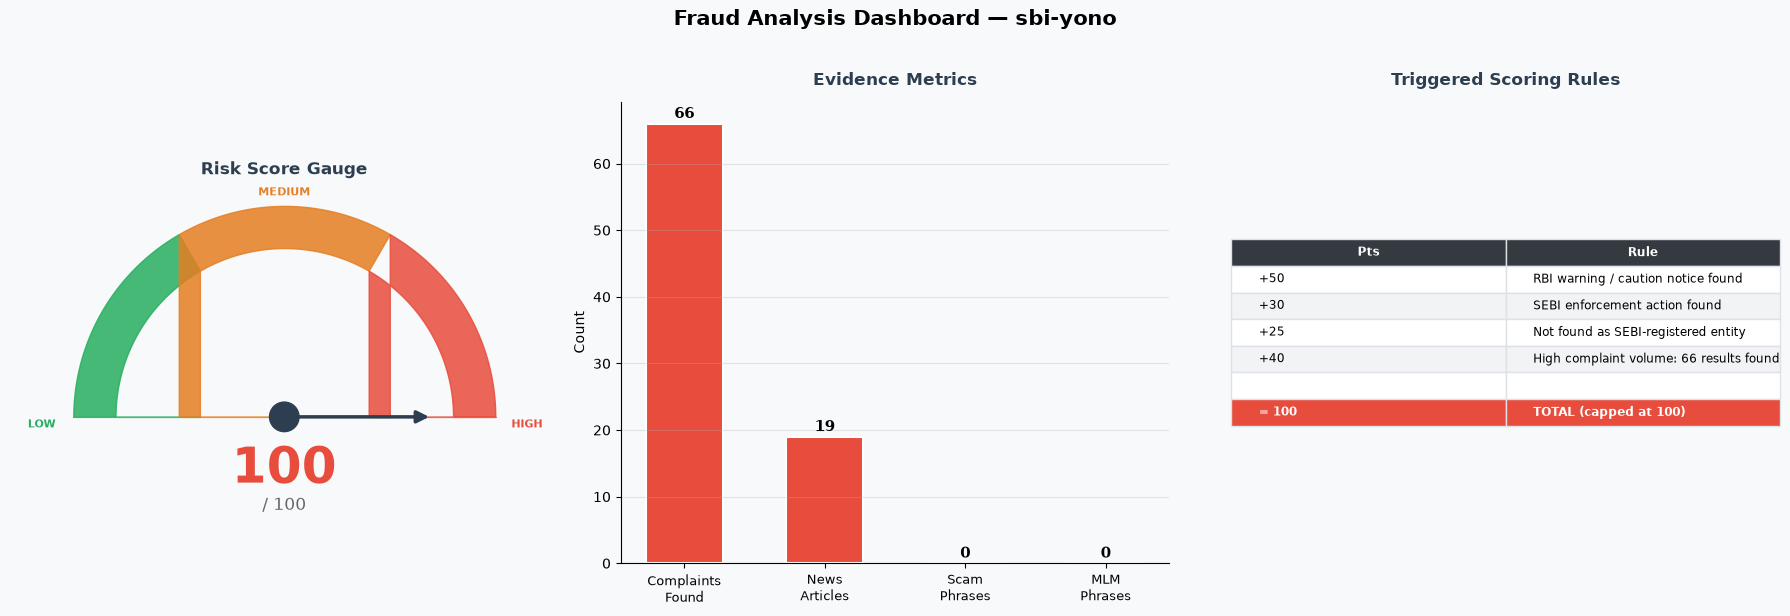

✅ Visualisation complete. Dashboard saved as fraud_dashboard.png


In [64]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#f8f9fa")
fig.suptitle(f"Fraud Analysis Dashboard — {company_name}",
             fontsize=15, fontweight="bold", y=1.02)

# ── 1) Risk Score Gauge ───────────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_aspect("equal")
ax1.set_xlim(-1.3, 1.3)
ax1.set_ylim(-0.5, 1.3)
ax1.axis("off")
ax1.set_facecolor("#f8f9fa")

# Gauge arc
theta = np.linspace(np.pi, 0, 300)
for i, (t1, t2, col) in enumerate(zip(
    [np.pi, np.pi*2/3, np.pi/3],
    [np.pi*2/3, np.pi/3, 0],
    ["#27ae60", "#e67e22", "#e74c3c"]
)):
    t = np.linspace(t1, t2, 100)
    ax1.fill_between(
        np.concatenate([0.8*np.cos(t), 1.0*np.cos(t[::-1])]),
        np.concatenate([0.8*np.sin(t), 1.0*np.sin(t[::-1])]),
        color=col, alpha=0.85
    )

# Needle
needle_angle = np.pi * (1 - risk["risk_score"] / 100)
ax1.annotate("", xy=(0.7*np.cos(needle_angle), 0.7*np.sin(needle_angle)),
             xytext=(0, 0),
             arrowprops=dict(arrowstyle="-|>", color="#2c3e50", lw=2.5,
                             mutation_scale=18))
circle = plt.Circle((0, 0), 0.07, color="#2c3e50", zorder=5)
ax1.add_patch(circle)

score_color = "#27ae60" if risk["risk_score"]<=30 else ("#e67e22" if risk["risk_score"]<=60 else "#e74c3c")
ax1.text(0, -0.25, f"{risk['risk_score']}", ha="center", va="center",
         fontsize=36, fontweight="bold", color=score_color)
ax1.text(0, -0.42, "/ 100", ha="center", va="center", fontsize=12, color="#666")
ax1.text(0, 1.15, "Risk Score Gauge", ha="center", fontsize=12,
         fontweight="bold", color="#2c3e50")
ax1.text(-1.15, -0.05, "LOW", ha="center", fontsize=8, color="#27ae60", fontweight="bold")
ax1.text(0, 1.05, "MEDIUM", ha="center", fontsize=8, color="#e67e22", fontweight="bold")
ax1.text(1.15, -0.05, "HIGH", ha="center", fontsize=8, color="#e74c3c", fontweight="bold")

# ── 2) Complaint / News / Scam Bar Chart ─────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor("#f8f9fa")
categories = ["Complaints\nFound", "News\nArticles", "Scam\nPhrases", "MLM\nPhrases"]
values     = [
    complaints["complaint_count"],
    news["article_count"],
    scam_phrases["scam_term_count"],
    mlm_phrases["mlm_count"],
]
bar_colors = []
for v, thresh in zip(values, [10, 3, 1, 1]):
    bar_colors.append("#e74c3c" if v > thresh else ("#e67e22" if v > 0 else "#27ae60"))

bars = ax2.bar(categories, values, color=bar_colors, width=0.55, edgecolor="white", linewidth=1.5)
ax2.set_title("Evidence Metrics", fontsize=12, fontweight="bold", color="#2c3e50", pad=12)
ax2.set_ylabel("Count", fontsize=10)
ax2.tick_params(axis="x", labelsize=9)
ax2.spines[["top", "right"]].set_visible(False)
ax2.set_facecolor("#f8f9fa")
ax2.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha="center", va="bottom", fontsize=11, fontweight="bold")

# ── 3) Triggered Rules Table ─────────────────────────────────────────────────
ax3 = axes[2]
ax3.axis("off")
ax3.set_facecolor("#f8f9fa")
ax3.set_title("Triggered Scoring Rules", fontsize=12,
              fontweight="bold", color="#2c3e50", pad=12)

if risk["triggered_rules"]:
    table_data = [[f"+{pts}", textwrap.fill(rule, 42)]
                  for rule, pts in risk["triggered_rules"]]
    table_data.append(["", ""])
    table_data.append([f"= {risk['risk_score']}", "TOTAL (capped at 100)"])

    t = ax3.table(
        cellText=table_data,
        colLabels=["Pts", "Rule"],
        loc="center",
        cellLoc="left",
    )
    t.auto_set_font_size(False)
    t.set_fontsize(8.5)
    t.scale(1, 1.6)

    for (row, col), cell in t.get_celld().items():
        cell.set_edgecolor("#dee2e6")
        if row == 0:
            cell.set_facecolor("#343a40")
            cell.set_text_props(color="white", fontweight="bold")
        elif row == len(table_data):   # total row
            cell.set_facecolor(score_color)
            cell.set_text_props(color="white", fontweight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#f1f3f5")
        else:
            cell.set_facecolor("white")
else:
    ax3.text(0.5, 0.5, "No rules triggered\n(very low risk)",
             ha="center", va="center", fontsize=14, color="#27ae60",
             fontweight="bold", transform=ax3.transAxes)

plt.tight_layout()
plt.savefig("./fraud_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor="#f8f9fa")
plt.show()
print("✅ Visualisation complete. Dashboard saved as fraud_dashboard.png")


## Section 19 — Export Report

In [65]:
import base64, pathlib
import json, re
# ── JSON Export ───────────────────────────────────────────────────────────────
json_path = "./fraud_report.json"
export_data = {k: v for k, v in evidence.items()}
export_data["generated_at"] = datetime.now().isoformat()

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(export_data, f, indent=2, default=str)
print(f"✅ JSON report saved → {json_path}")

# ── HTML Export ───────────────────────────────────────────────────────────────
html_path = "./fraud_report.html"

# Embed dashboard image
img_b64 = ""
try:
    img_bytes = pathlib.Path("./fraud_dashboard.png").read_bytes()
    img_b64   = base64.b64encode(img_bytes).decode()
except Exception:
    pass

# Convert llm markdown → HTML (simple converter)
def md_to_html(text: str) -> str:
    if not text:
        return "<p><em>LLM assessment not available.</em></p>"
    import html as html_lib
    lines = text.split("\n")
    out = []
    in_list = False
    for line in lines:
        if line.startswith("# "):
            if in_list: out.append("</ul>"); in_list = False
            out.append(f"<h1>{html_lib.escape(line[2:])}</h1>")
        elif line.startswith("## "):
            if in_list: out.append("</ul>"); in_list = False
            out.append(f"<h2>{html_lib.escape(line[3:])}</h2>")
        elif line.startswith("### "):
            if in_list: out.append("</ul>"); in_list = False
            out.append(f"<h3>{html_lib.escape(line[4:])}</h3>")
        elif line.startswith("- [ ] "):
            if not in_list: out.append("<ul>"); in_list = True
            out.append(f'<li><input type="checkbox"> {html_lib.escape(line[6:])}</li>')
        elif line.startswith("- "):
            if not in_list: out.append("<ul>"); in_list = True
            out.append(f"<li>{html_lib.escape(line[2:])}</li>")
        elif line.strip() == "":
            if in_list: out.append("</ul>"); in_list = False
            out.append("<br>")
        else:
            if in_list: out.append("</ul>"); in_list = False
            # Bold
            processed = re.sub(r"\*\*(.+?)\*\*", r"<strong>\1</strong>", html_lib.escape(line))
            out.append(f"<p>{processed}</p>")
    if in_list:
        out.append("</ul>")
    return "\n".join(out)


risk_color_css = "#27ae60" if risk["risk_score"]<=30 else ("#e67e22" if risk["risk_score"]<=60 else "#e74c3c")
llm_html = md_to_html(llm_assessment)

rules_rows = "".join(
    f"<tr><td style='color:{risk_color_css};font-weight:bold;'>+{pts}</td><td>{rule}</td></tr>"
    for rule, pts in risk["triggered_rules"]
)

html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1.0">
<title>Fraud Analysis Report — {company_name}</title>
<style>
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{ font-family: 'Segoe UI', Arial, sans-serif; background: #f0f2f5; color: #2c3e50; }}
  .container {{ max-width: 960px; margin: 32px auto; padding: 0 20px 60px; }}
  .header {{ background: linear-gradient(135deg,#1a1a2e,#16213e,#0f3460);
             color:white; padding:36px 40px; border-radius:16px; margin-bottom:28px; }}
  .header h1 {{ font-size:28px; margin-bottom:6px; }}
  .header .meta {{ opacity:.65; font-size:13px; margin-bottom:20px; }}
  .header-grid {{ display:flex; gap:40px; flex-wrap:wrap; }}
  .header-item label {{ font-size:11px; opacity:.6; text-transform:uppercase; display:block; }}
  .header-item .val {{ font-size:20px; font-weight:700; }}
  .score-val {{ font-size:40px !important; color:{risk_color_css}; }}
  .cards {{ display:grid; grid-template-columns:repeat(auto-fit,minmax(200px,1fr));
            gap:16px; margin-bottom:28px; }}
  .card {{ background:white; border-radius:12px; padding:20px; box-shadow:0 2px 8px rgba(0,0,0,.06); }}
  .card label {{ font-size:11px; color:#888; text-transform:uppercase; }}
  .card .cval {{ font-size:20px; font-weight:700; margin-top:4px; }}
  .section {{ background:white; border-radius:12px; padding:28px 32px;
              box-shadow:0 2px 8px rgba(0,0,0,.06); margin-bottom:24px; }}
  .section h2 {{ font-size:17px; font-weight:700; margin-bottom:16px;
                 padding-bottom:10px; border-bottom:2px solid #f0f2f5; }}
  table {{ width:100%; border-collapse:collapse; font-size:13px; }}
  th {{ background:#343a40; color:white; padding:10px 14px; text-align:left; }}
  td {{ padding:10px 14px; border-bottom:1px solid #f0f2f5; }}
  tr:nth-child(even) td {{ background:#f8f9fa; }}
  .llm-section h1 {{ font-size:22px; color:#1a1a2e; margin:16px 0 8px; }}
  .llm-section h2 {{ font-size:17px; color:#16213e; margin:14px 0 8px; }}
  .llm-section h3 {{ font-size:14px; color:#0f3460; margin:12px 0 6px; }}
  .llm-section p  {{ line-height:1.7; margin-bottom:10px; }}
  .llm-section ul {{ padding-left:20px; margin-bottom:10px; }}
  .llm-section li {{ margin-bottom:4px; line-height:1.6; }}
  .badge {{ display:inline-block; padding:4px 12px; border-radius:20px;
            font-weight:700; font-size:14px; color:white;
            background:{risk_color_css}; }}
  .dashboard img {{ max-width:100%; border-radius:8px; }}
  .footer {{ text-align:center; color:#aaa; font-size:12px; margin-top:40px; }}
</style>
</head>
<body>
<div class="container">

  <div class="header">
    <h1>🔍 Fraud Analysis Report</h1>
    <div class="meta">Generated: {datetime.now().strftime('%d %B %Y, %H:%M IST')}</div>
    <div class="header-grid">
      <div class="header-item"><label>Company</label><div class="val">{company_name}</div></div>
      <div class="header-item"><label>Scheme</label><div class="val">{scheme_name}</div></div>
      <div class="header-item"><label>Website</label><div class="val">{website_url}</div></div>
      <div class="header-item"><label>Risk Score</label>
        <div class="val score-val">{risk['risk_score']} / 100</div></div>
      <div class="header-item"><label>Risk Level</label>
        <div class="val"><span class="badge">{risk['risk_level']}</span></div></div>
    </div>
  </div>

  <div class="cards">
    <div class="card">
      <label>Company Registry</label>
      <div class="cval" style="color:{'#27ae60' if company_info['company_found'] else '#e74c3c'}">
        {'✅ Found' if company_info['company_found'] else '❌ Not Found'}</div></div>
    <div class="card">
      <label>RBI Warning</label>
      <div class="cval" style="color:{'#e74c3c' if rbi_check['rbi_warning_found'] else '#27ae60'}">
        {'⚠️ Found' if rbi_check['rbi_warning_found'] else '✅ None'}</div></div>
    <div class="card">
      <label>SEBI Registered</label>
      <div class="cval" style="color:{'#27ae60' if sebi_check['sebi_registered'] else '#e67e22'}">
        {'✅ Yes' if sebi_check['sebi_registered'] else '⚠️ Unconfirmed'}</div></div>
    <div class="card">
      <label>SEBI Enforcement</label>
      <div class="cval" style="color:{'#e74c3c' if sebi_check['enforcement_found'] else '#27ae60'}">
        {'❌ Found' if sebi_check['enforcement_found'] else '✅ None'}</div></div>
    <div class="card">
      <label>Domain Age</label>
      <div class="cval">{str(domain_info.get('domain_age_days','N/A')) + ' days' if domain_info.get('domain_age_days') else 'Unknown'}</div></div>
    <div class="card">
      <label>Complaints Found</label>
      <div class="cval" style="color:{'#e74c3c' if complaints['complaint_count']>10 else '#27ae60'}">{complaints['complaint_count']}</div></div>
    <div class="card">
      <label>Scam Phrases</label>
      <div class="cval" style="color:{'#e74c3c' if scam_phrases['scam_term_count']>0 else '#27ae60'}">{scam_phrases['scam_term_count']}</div></div>
    <div class="card">
      <label>MLM Phrases</label>
      <div class="cval" style="color:{'#e74c3c' if mlm_phrases['mlm_count']>0 else '#27ae60'}">{mlm_phrases['mlm_count']}</div></div>
  </div>

  {'<div class="section dashboard"><h2>📊 Analysis Dashboard</h2><img src="data:image/png;base64,' + img_b64 + '" alt="Dashboard"></div>' if img_b64 else ''}

  <div class="section">
    <h2>⚖️ Triggered Scoring Rules</h2>
    <table>
      <tr><th>Points</th><th>Rule</th></tr>
      {rules_rows}
      <tr style="background:#f8f9fa;font-weight:700;">
        <td style="color:{risk_color_css}">= {risk['risk_score']}</td>
        <td>TOTAL RISK SCORE (capped at 100)</td>
      </tr>
    </table>
  </div>

  <div class="section llm-section">
    <h2>🤖 AI Assessment</h2>
    {llm_html}
  </div>

  <div class="footer">
    Artha-Darshan FinSafe Intelligence Engine &nbsp;|&nbsp;
    This report is AI-assisted analysis and does not constitute legal or financial advice.
  </div>
</div>
</body>
</html>"""

with open(html_path, "w", encoding="utf-8") as f:
    f.write(html_content)
print(f"✅ HTML report saved → {html_path}")

print("\n" + "="*60)
print("  EXPORT COMPLETE")
print("="*60)
print(f"  📄 JSON  : {json_path}")
print(f"  🌐 HTML  : {html_path}")
print(f"  📊 Chart : /home/claude/fraud_dashboard.png")


✅ JSON report saved → ./fraud_report.json
✅ HTML report saved → ./fraud_report.html

  EXPORT COMPLETE
  📄 JSON  : ./fraud_report.json
  🌐 HTML  : ./fraud_report.html
  📊 Chart : /home/claude/fraud_dashboard.png


## ✅ Pipeline Complete